# Time Series Forecasting — USD to Australian Dollar Exchange Rate
**Objective:** Apply ARIMA and Exponential Smoothing to forecast future USD/AUD exchange rates using historical data from 1990 to 2010.

**Dataset:** `exchange_rate.csv` — 7,588 daily observations (Jan 1990 – Oct 2010)

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# Error metric helpers
def mae(y, yhat):  return mean_absolute_error(y, yhat)
def rmse(y, yhat): return np.sqrt(mean_squared_error(y, yhat))
def mape(y, yhat): return np.mean(np.abs((np.array(y)-np.array(yhat))/np.array(y)))*100

print('All libraries loaded.')

All libraries loaded.


---
## Part 1 — Data Preparation and Exploration

### 1a. Data Loading

In [2]:
# Load dataset — same filename as provided
df = pd.read_csv('exchange_rate.csv')

# Parse date column
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df.set_index('date', inplace=True)
df.index.freq = 'D'   # daily frequency

print('Shape:', df.shape)
print(f'Date range: {df.index.min().date()}  →  {df.index.max().date()}')
print(f'Duration  : ~{(df.index.max()-df.index.min()).days/365.25:.1f} years')
df.head()

Shape: (7588, 1)
Date range: 1990-01-01  →  2010-10-10
Duration  : ~20.8 years


,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [3]:
# Basic statistics
print('=== Exchange Rate Statistics ===')
print(df['Ex_rate'].describe().round(6))
print(f'\nSkewness : {df["Ex_rate"].skew():.4f}')
print(f'Kurtosis : {df["Ex_rate"].kurt():.4f}')

=== Exchange Rate Statistics ===
count    7588.000000
mean        0.776974
std         0.136620
min         0.483297
25%         0.701422
50%         0.761377
75%         0.873477
max         1.102536
Name: Ex_rate, dtype: float64

Skewness : 0.2611
Kurtosis : -0.3255


In [4]:
# Missing values check
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.sum() > 0
      else '  No missing values found.')

Missing Values:
  No missing values found.


### 1b. Initial Time Series Exploration

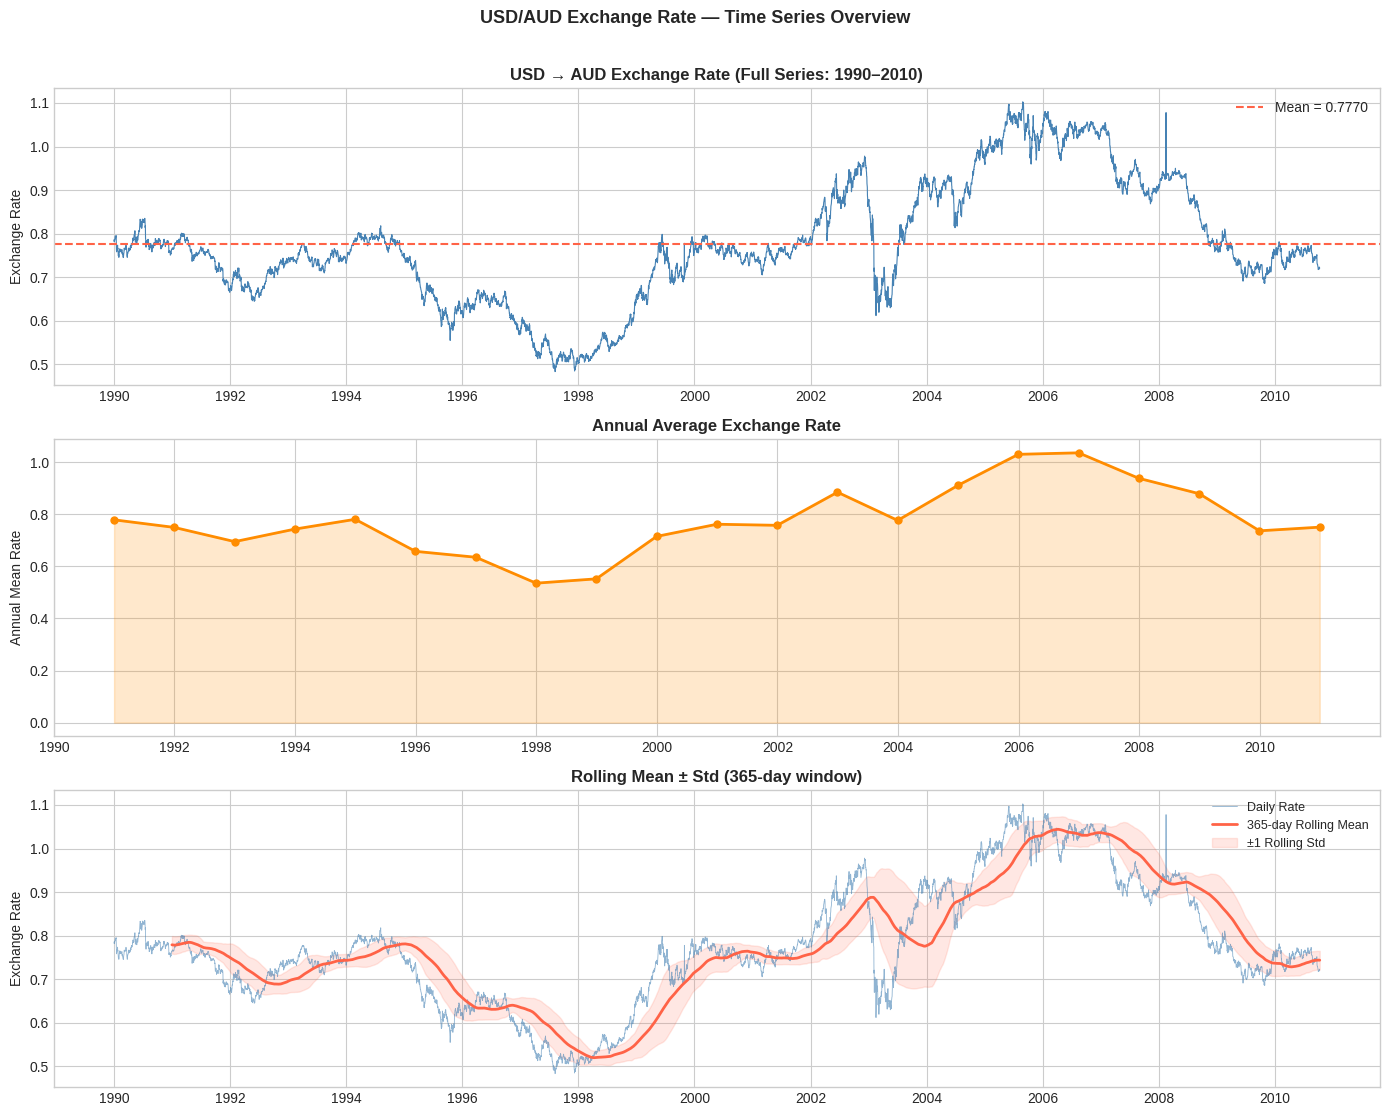

In [5]:
# Full time series plot
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Full series
axes[0].plot(df.index, df['Ex_rate'], color='steelblue', lw=0.8)
axes[0].set_title('USD → AUD Exchange Rate (Full Series: 1990–2010)',
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Exchange Rate')
axes[0].axhline(df['Ex_rate'].mean(), color='tomato', linestyle='--',
                lw=1.5, label=f'Mean = {df["Ex_rate"].mean():.4f}')
axes[0].legend()

# Annual resampled
annual = df['Ex_rate'].resample('YE').mean()
axes[1].plot(annual.index, annual.values, 'o-',
             color='darkorange', lw=2, ms=5)
axes[1].fill_between(annual.index, annual.values,
                     alpha=0.2, color='darkorange')
axes[1].set_title('Annual Average Exchange Rate', fontweight='bold')
axes[1].set_ylabel('Annual Mean Rate')

# Rolling statistics
roll_mean = df['Ex_rate'].rolling(window=365).mean()
roll_std  = df['Ex_rate'].rolling(window=365).std()
axes[2].plot(df.index, df['Ex_rate'], color='steelblue',
             lw=0.6, alpha=0.6, label='Daily Rate')
axes[2].plot(roll_mean.index, roll_mean, color='tomato',
             lw=2, label='365-day Rolling Mean')
axes[2].fill_between(roll_mean.index,
                     roll_mean - roll_std,
                     roll_mean + roll_std,
                     alpha=0.15, color='tomato',
                     label='±1 Rolling Std')
axes[2].set_title('Rolling Mean ± Std (365-day window)', fontweight='bold')
axes[2].set_ylabel('Exchange Rate')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('USD/AUD Exchange Rate — Time Series Overview',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

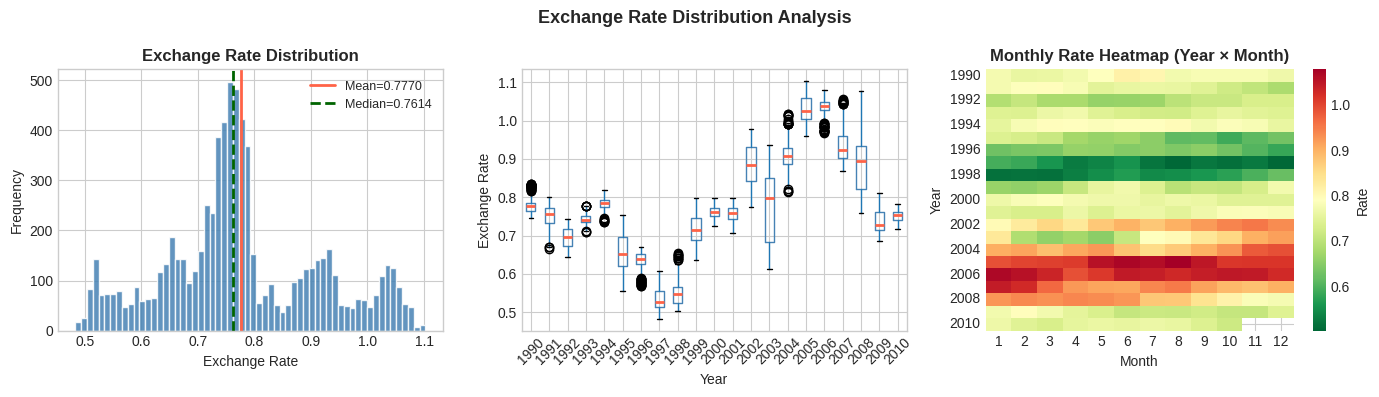

In [6]:
# Distribution of exchange rate values
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df['Ex_rate'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.85)
axes[0].axvline(df['Ex_rate'].mean(), color='tomato', lw=2,
                label=f'Mean={df["Ex_rate"].mean():.4f}')
axes[0].axvline(df['Ex_rate'].median(), color='darkgreen', lw=2,
                linestyle='--', label=f'Median={df["Ex_rate"].median():.4f}')
axes[0].set_title('Exchange Rate Distribution', fontweight='bold')
axes[0].set_xlabel('Exchange Rate')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=9)

# Annual box plots
df_box = df.copy()
df_box['Year'] = df_box.index.year
df_box.boxplot(column='Ex_rate', by='Year', ax=axes[1],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='tomato', linewidth=2))
axes[1].set_title('Annual Box Plots', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Exchange Rate')
axes[1].tick_params(axis='x', rotation=45)
plt.sca(axes[1]); plt.title('')

# Monthly average heatmap
df_box['Month'] = df_box.index.month
pivot = df_box.pivot_table(values='Ex_rate', index='Year', columns='Month')
sns.heatmap(pivot, cmap='RdYlGn_r', ax=axes[2],
            cbar_kws={'label':'Rate'}, linewidths=0)
axes[2].set_title('Monthly Rate Heatmap (Year × Month)', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Year')

plt.suptitle('Exchange Rate Distribution Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

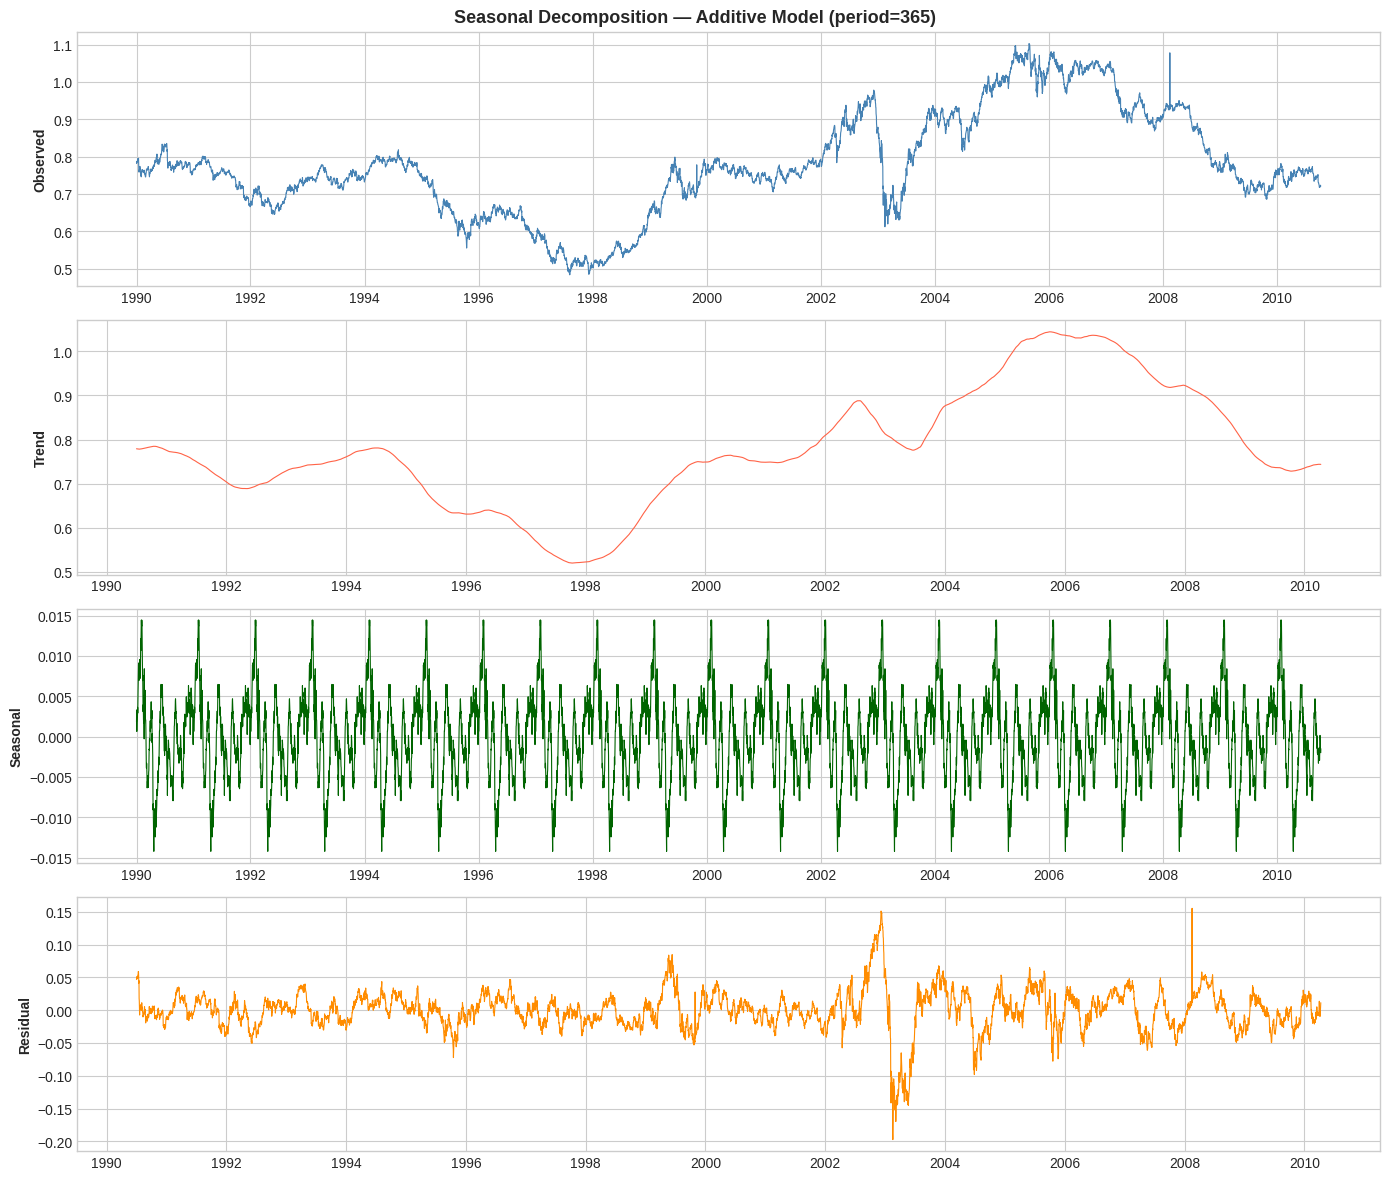

In [7]:
# Seasonal decomposition
decomp = seasonal_decompose(df['Ex_rate'], model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
components = [
    (decomp.observed,  'Observed',  'steelblue'),
    (decomp.trend,     'Trend',     'tomato'),
    (decomp.seasonal,  'Seasonal',  'darkgreen'),
    (decomp.resid,     'Residual',  'darkorange')
]
for ax, (comp, label, color) in zip(axes, components):
    ax.plot(comp.index, comp, color=color, lw=0.8)
    ax.set_ylabel(label, fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('Seasonal Decomposition — Additive Model (period=365)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1c. Stationarity Testing

In [8]:
def adf_test(series, name='Series'):
    """Augmented Dickey-Fuller test for stationarity."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test — {name}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.6f}')
    print(f'  Critical (1%) : {result[4]["1%"]:.4f}')
    print(f'  Critical (5%) : {result[4]["5%"]:.4f}')
    stationary = result[1] < 0.05
    print(f'  → {"STATIONARY" if stationary else "NON-STATIONARY"} (p {"<" if stationary else ">="} 0.05)')
    print()
    return stationary

# Test original series
stat_orig = adf_test(df['Ex_rate'], 'Original Series')

# First difference
df['Ex_rate_diff1'] = df['Ex_rate'].diff()
stat_d1 = adf_test(df['Ex_rate_diff1'].dropna(), '1st Difference')

ADF Test — Original Series
  ADF Statistic : -1.6650
  p-value       : 0.449233
  Critical (1%) : -3.4312
  Critical (5%) : -2.8619
  → NON-STATIONARY (p >= 0.05)



ADF Test — 1st Difference
  ADF Statistic : -99.3934
  p-value       : 0.000000
  Critical (1%) : -3.4312
  Critical (5%) : -2.8619
  → STATIONARY (p < 0.05)



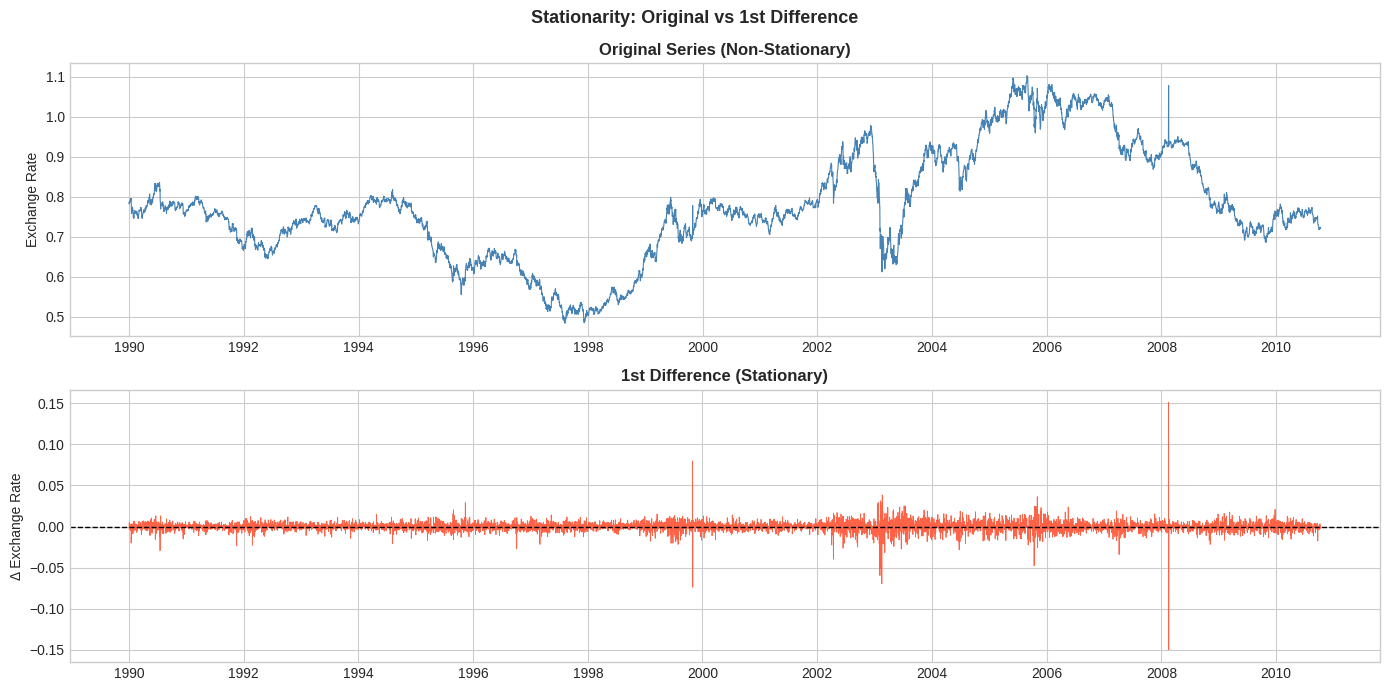

In [9]:
# Plot original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df.index, df['Ex_rate'], color='steelblue', lw=0.8)
axes[0].set_title('Original Series (Non-Stationary)', fontweight='bold')
axes[0].set_ylabel('Exchange Rate')

axes[1].plot(df.index[1:], df['Ex_rate_diff1'].dropna(),
             color='tomato', lw=0.6)
axes[1].axhline(0, color='black', lw=1, linestyle='--')
axes[1].set_title('1st Difference (Stationary)', fontweight='bold')
axes[1].set_ylabel('Δ Exchange Rate')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

plt.suptitle('Stationarity: Original vs 1st Difference',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1d. Train / Test Split

Train: 7,408 obs  (1990-01-01 → 2010-04-13)
Test : 180  obs  (2010-04-14 → 2010-10-10)


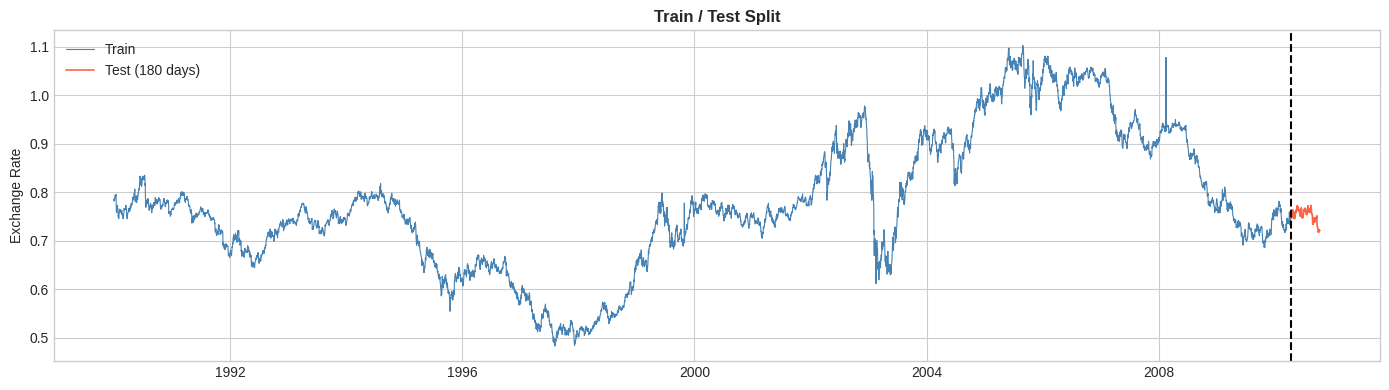

In [10]:
# Use last 180 days as test set, rest for training
TEST_STEPS = 180
series     = df['Ex_rate'].copy()

train = series[:-TEST_STEPS]
test  = series[-TEST_STEPS:]

print(f'Train: {len(train):,} obs  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test : {len(test):,}  obs  ({test.index.min().date()} → {test.index.max().date()})')

plt.figure(figsize=(14, 4))
plt.plot(train.index, train, color='steelblue', lw=0.8, label='Train')
plt.plot(test.index,  test,  color='tomato',    lw=1.2, label='Test (180 days)')
plt.axvline(test.index[0], color='black', linestyle='--', lw=1.5)
plt.title('Train / Test Split', fontweight='bold', fontsize=12)
plt.ylabel('Exchange Rate')
plt.legend()
plt.tight_layout()
plt.show()

---
## Part 2 — ARIMA Model

### 2a. ACF and PACF — Parameter Selection

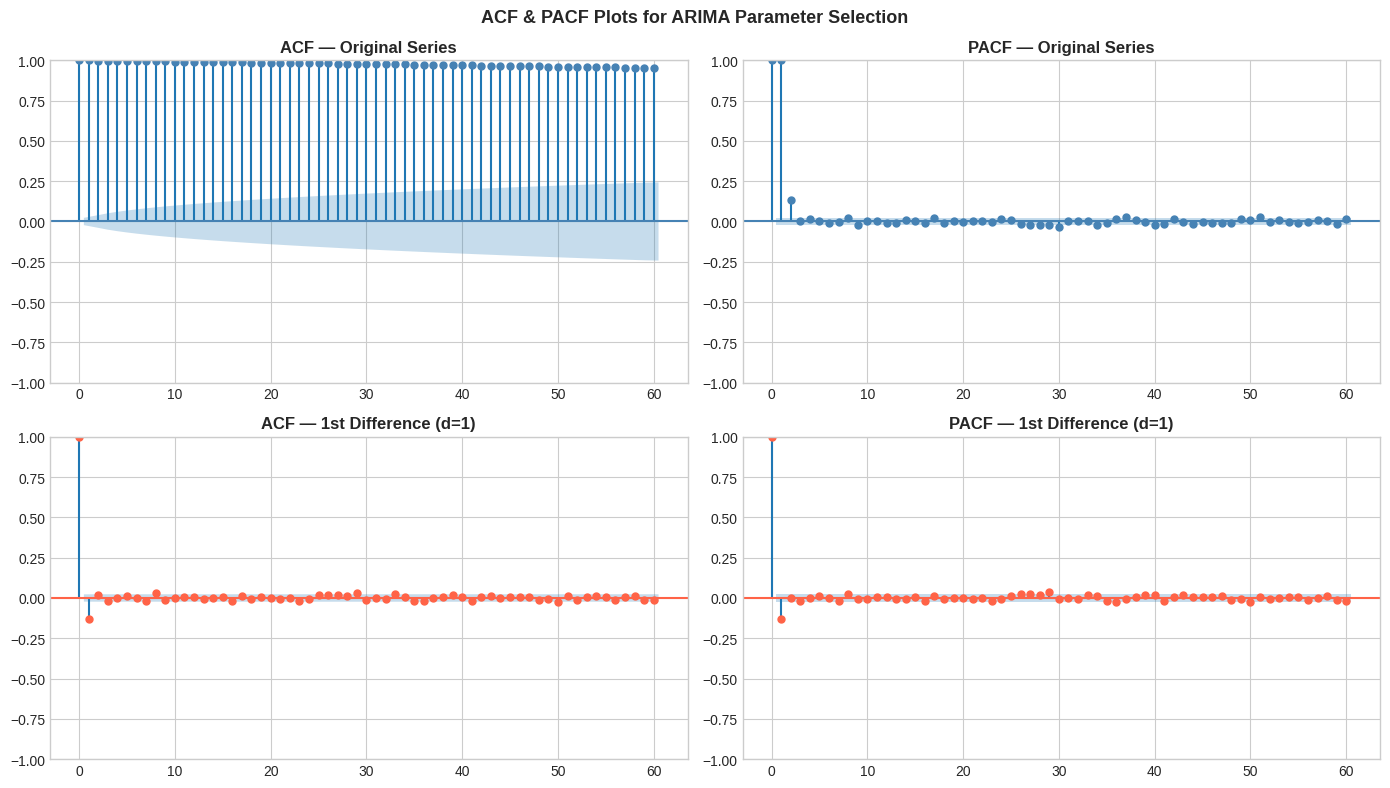

Parameter interpretation:
  d = 1  (1 difference needed to achieve stationarity)
  p = 1-2 (PACF cuts off after lag 1–2 in differenced series)
  q = 1-2 (ACF cuts off after lag 1–2 in differenced series)


In [11]:
# ACF and PACF on differenced series
diff1 = train.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Original ACF/PACF
plot_acf(train,  lags=60, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('ACF — Original Series', fontweight='bold')
plot_pacf(train, lags=60, ax=axes[0][1], color='steelblue', method='ywm')
axes[0][1].set_title('PACF — Original Series', fontweight='bold')

# Differenced ACF/PACF
plot_acf(diff1,  lags=60, ax=axes[1][0], color='tomato')
axes[1][0].set_title('ACF — 1st Difference (d=1)', fontweight='bold')
plot_pacf(diff1, lags=60, ax=axes[1][1], color='tomato', method='ywm')
axes[1][1].set_title('PACF — 1st Difference (d=1)', fontweight='bold')

plt.suptitle('ACF & PACF Plots for ARIMA Parameter Selection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Parameter interpretation:')
print('  d = 1  (1 difference needed to achieve stationarity)')
print('  p = 1-2 (PACF cuts off after lag 1–2 in differenced series)')
print('  q = 1-2 (ACF cuts off after lag 1–2 in differenced series)')

### 2b. ARIMA Model Selection via AIC Grid

In [12]:
# Grid search over p, d, q
best_aic   = np.inf
best_order = None
aic_results = []

for p in range(0, 4):
    for d in [1]:
        for q in range(0, 4):
            try:
                m = ARIMA(train, order=(p, d, q)).fit()
                aic_results.append({'p':p,'d':d,'q':q,'AIC':round(m.aic,2),'BIC':round(m.bic,2)})
                if m.aic < best_aic:
                    best_aic   = m.aic
                    best_order = (p, d, q)
            except:
                pass

aic_df = pd.DataFrame(aic_results).sort_values('AIC').reset_index(drop=True)
print('Top 10 ARIMA configurations by AIC:')
print(aic_df.head(10).to_string(index=False))
print(f'\nBest order: ARIMA{best_order}  (AIC = {best_aic:.2f})')

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top 10 ARIMA configurations by AIC:
 p  d  q       AIC       BIC
 2  1  3 -54665.74 -54624.28
 1  1  0 -54665.27 -54651.45
 0  1  1 -54663.81 -54649.99
 1  1  1 -54663.28 -54642.55
 2  1  0 -54663.28 -54642.55
 3  1  0 -54663.08 -54635.44
 0  1  3 -54662.99 -54635.35
 0  1  2 -54662.88 -54642.15
 1  1  2 -54662.40 -54634.76
 2  1  1 -54661.27 -54633.63

Best order: ARIMA(2, 1, 3)  (AIC = -54665.74)


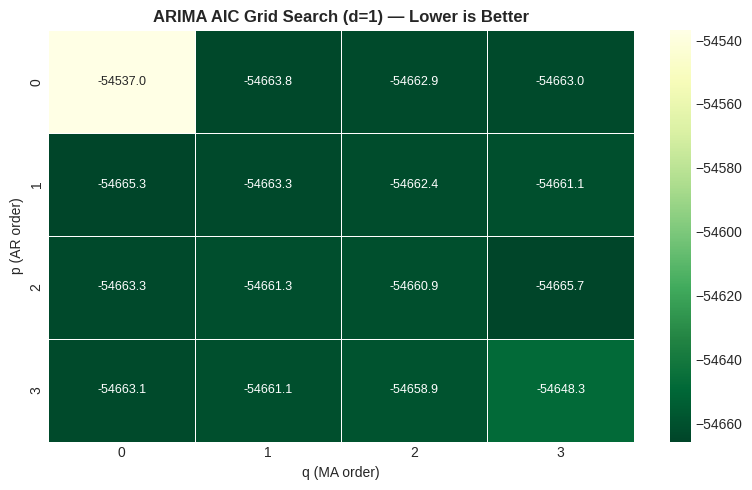

In [13]:
# AIC heatmap (p vs q, d=1)
aic_pivot = aic_df.pivot_table(index='p', columns='q', values='AIC')

plt.figure(figsize=(8, 5))
sns.heatmap(aic_pivot, annot=True, fmt='.1f', cmap='YlGn_r',
            linewidths=0.5, annot_kws={'size': 9})
plt.title('ARIMA AIC Grid Search (d=1) — Lower is Better',
          fontweight='bold')
plt.xlabel('q (MA order)')
plt.ylabel('p (AR order)')
plt.tight_layout()
plt.show()

### 2c. ARIMA Model Fitting

In [14]:
# Fit best ARIMA model
arima_model = ARIMA(train, order=best_order).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7408
Model:                 ARIMA(2, 1, 3)   Log Likelihood               27338.869
Date:                Thu, 16 Apr 2026   AIC                         -54665.738
Time:                        09:17:30   BIC                         -54624.277
Sample:                    01-01-1990   HQIC                        -54651.492
                         - 04-13-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6587      0.124     -5.309      0.000      -0.902      -0.415
ar.L2         -0.7992      0.116     -6.904      0.000      -1.026      -0.572
ma.L1          0.5265      0.124      4.242      0.0

### 2d. ARIMA Residual Diagnostics

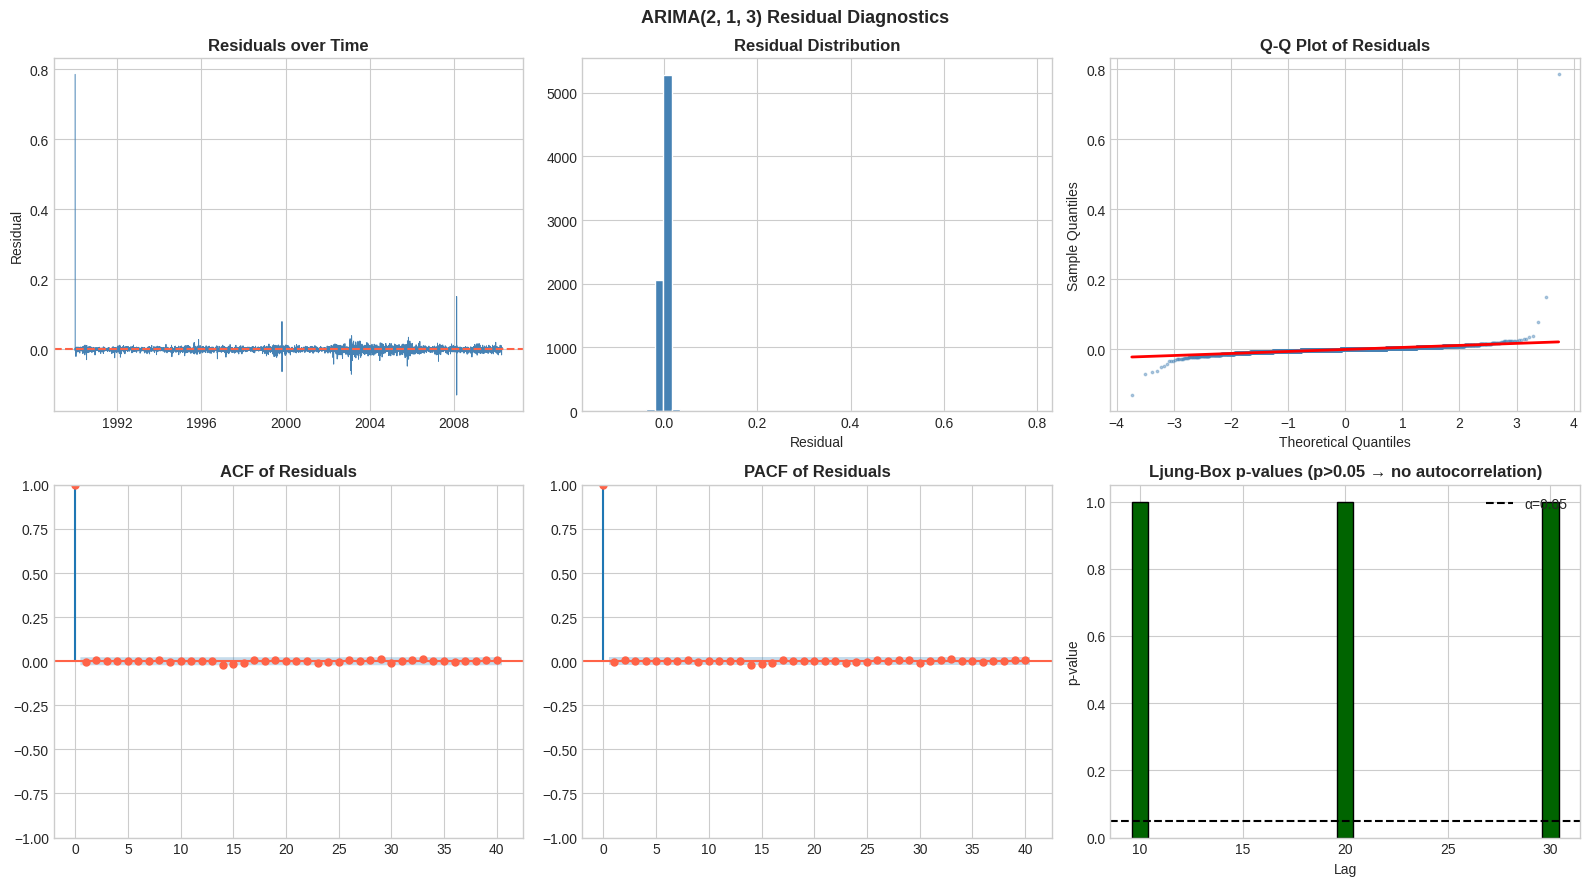

Ljung-Box Test:
     lb_stat  lb_pvalue
10  1.067567   0.999768
20  6.285053   0.998454
30  9.193259   0.999907

→ p > 0.05 at all lags = residuals are white noise (good model fit)


In [15]:
residuals = arima_model.resid

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Residuals over time
axes[0][0].plot(residuals.index, residuals, color='steelblue', lw=0.7)
axes[0][0].axhline(0, color='tomato', linestyle='--', lw=1.5)
axes[0][0].set_title('Residuals over Time', fontweight='bold')
axes[0][0].set_ylabel('Residual')
axes[0][0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0][0].xaxis.set_major_locator(mdates.YearLocator(4))

# Residual histogram
axes[0][1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[0][1].set_title('Residual Distribution', fontweight='bold')
axes[0][1].set_xlabel('Residual')

# Q-Q plot
from scipy import stats
(osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
axes[0][2].scatter(osm, osr, s=3, alpha=0.4, color='steelblue')
axes[0][2].plot(osm, slope*np.array(osm)+intercept, 'r-', lw=2)
axes[0][2].set_title('Q-Q Plot of Residuals', fontweight='bold')
axes[0][2].set_xlabel('Theoretical Quantiles')
axes[0][2].set_ylabel('Sample Quantiles')

# ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1][0], color='tomato')
axes[1][0].set_title('ACF of Residuals', fontweight='bold')

# PACF of residuals
plot_pacf(residuals, lags=40, ax=axes[1][1],
          color='tomato', method='ywm')
axes[1][1].set_title('PACF of Residuals', fontweight='bold')

# Ljung-Box test
lb = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
axes[1][2].bar(lb.index, lb['lb_pvalue'],
               color=['darkgreen' if p > 0.05 else 'tomato'
                      for p in lb['lb_pvalue']], edgecolor='black')
axes[1][2].axhline(0.05, color='black', linestyle='--',
                   lw=1.5, label='α=0.05')
axes[1][2].set_title('Ljung-Box p-values (p>0.05 → no autocorrelation)',
                      fontweight='bold')
axes[1][2].set_xlabel('Lag')
axes[1][2].set_ylabel('p-value')
axes[1][2].legend()

plt.suptitle(f'ARIMA{best_order} Residual Diagnostics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Ljung-Box Test:')
print(lb.to_string())
print('\n→ p > 0.05 at all lags = residuals are white noise (good model fit)')

### 2e. ARIMA Forecasting

In [16]:
# Out-of-sample forecast
arima_forecast = arima_model.forecast(steps=TEST_STEPS)
arima_ci = arima_model.get_forecast(steps=TEST_STEPS).conf_int()

# Metrics
arima_mae  = mae(test.values,  arima_forecast.values)
arima_rmse = rmse(test.values, arima_forecast.values)
arima_mape = mape(test.values, arima_forecast.values)

print(f'ARIMA{best_order} Forecast Metrics:')
print(f'  MAE  : {arima_mae:.6f}')
print(f'  RMSE : {arima_rmse:.6f}')
print(f'  MAPE : {arima_mape:.4f}%')

ARIMA(2, 1, 3) Forecast Metrics:
  MAE  : 0.010304
  RMSE : 0.013045
  MAPE : 1.3789%


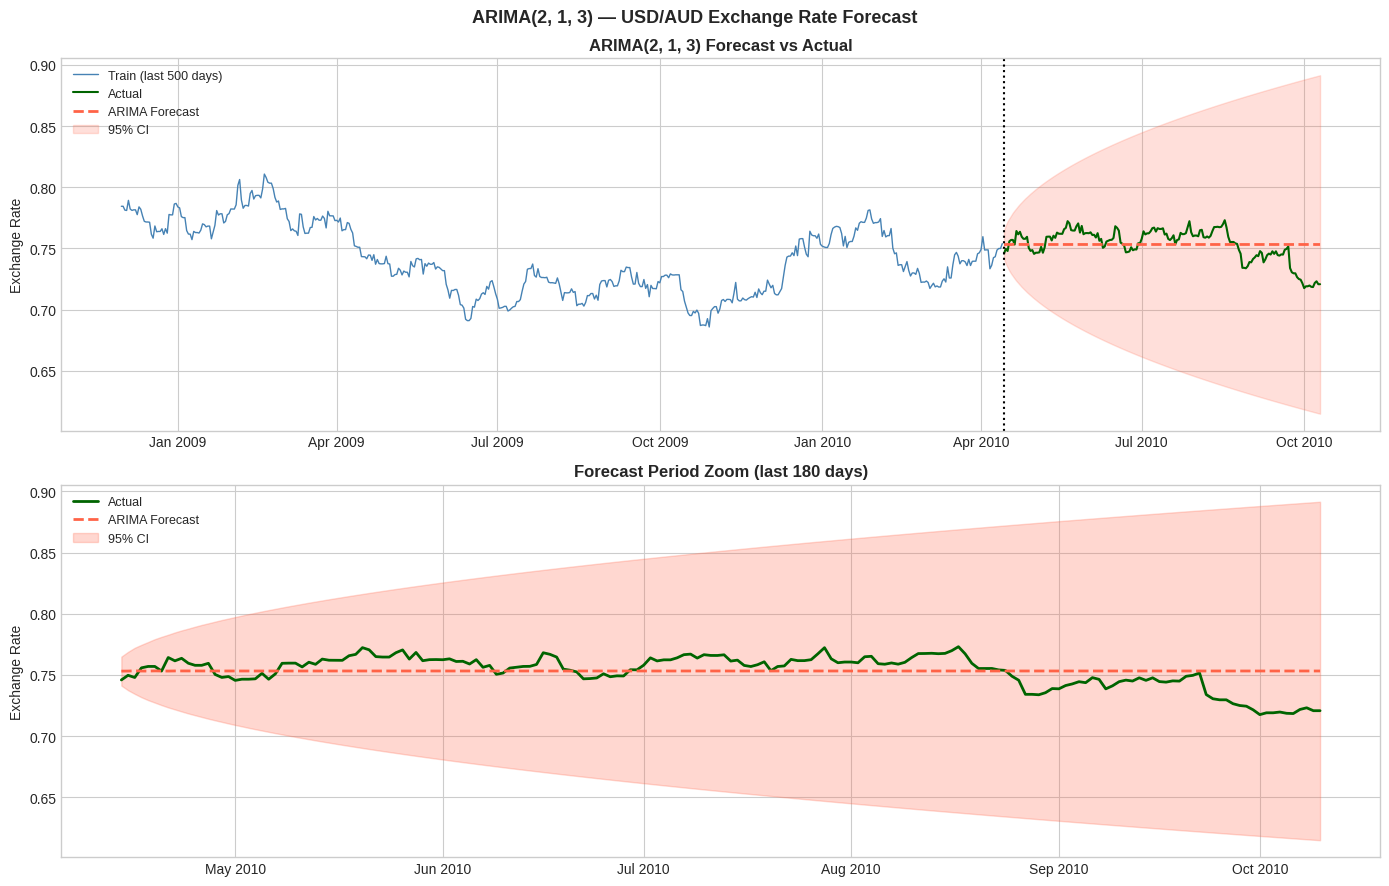

In [17]:
# Plot ARIMA forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Full context
context = train[-500:]
axes[0].plot(context.index, context, color='steelblue',
             lw=1, label='Train (last 500 days)')
axes[0].plot(test.index, test, color='darkgreen',
             lw=1.5, label='Actual')
axes[0].plot(arima_forecast.index, arima_forecast,
             color='tomato', lw=2, linestyle='--',
             label='ARIMA Forecast')
axes[0].fill_between(arima_ci.index,
                     arima_ci.iloc[:, 0],
                     arima_ci.iloc[:, 1],
                     alpha=0.2, color='tomato',
                     label='95% CI')
axes[0].axvline(test.index[0], color='black',
                linestyle=':', lw=1.5)
axes[0].set_title(f'ARIMA{best_order} Forecast vs Actual',
                   fontweight='bold', fontsize=12)
axes[0].set_ylabel('Exchange Rate')
axes[0].legend(fontsize=9)

# Forecast period zoom
axes[1].plot(test.index, test.values, color='darkgreen',
             lw=2, label='Actual')
axes[1].plot(arima_forecast.index, arima_forecast.values,
             color='tomato', lw=2, linestyle='--',
             label='ARIMA Forecast')
axes[1].fill_between(arima_ci.index,
                     arima_ci.iloc[:, 0],
                     arima_ci.iloc[:, 1],
                     alpha=0.25, color='tomato', label='95% CI')
axes[1].set_title('Forecast Period Zoom (last 180 days)',
                   fontweight='bold', fontsize=12)
axes[1].set_ylabel('Exchange Rate')
axes[1].legend(fontsize=9)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle(f'ARIMA{best_order} — USD/AUD Exchange Rate Forecast',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Exponential Smoothing Models

### 3a. Model Selection

In [18]:
# Compare all three ES variants
print('Exponential Smoothing Model Selection:')
print()

# 1. Simple Exponential Smoothing (no trend, no seasonality)
ses = SimpleExpSmoothing(train).fit(optimized=True)
print(f'Simple ES           — AIC: {ses.aic:.2f}  alpha={ses.params["smoothing_level"]:.4f}')

# 2. Holt's Linear (trend, no seasonality)
holt = Holt(train).fit(optimized=True)
print(f"Holt's Linear       — AIC: {holt.aic:.2f}  "
      f"alpha={holt.params['smoothing_level']:.4f}  "
      f"beta={holt.params['smoothing_trend']:.4f}")

# 3. Holt-Winters Additive (trend + seasonality)
hw_add = ExponentialSmoothing(train, trend='add',
                               seasonal='add',
                               seasonal_periods=365).fit(optimized=True)
print(f'Holt-Winters Add    — AIC: {hw_add.aic:.2f}')

# 4. Holt-Winters Multiplicative
try:
    hw_mul = ExponentialSmoothing(train, trend='add',
                                   seasonal='mul',
                                   seasonal_periods=365).fit(optimized=True)
    print(f'Holt-Winters Mul    — AIC: {hw_mul.aic:.2f}')
except Exception as e:
    print(f'Holt-Winters Mul    — Failed: {e}')
    hw_mul = None

Exponential Smoothing Model Selection:

Simple ES           — AIC: -75695.21  alpha=0.8691
Holt's Linear       — AIC: -75634.74  alpha=0.8688  beta=0.0090


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Holt-Winters Add    — AIC: -75145.83


Holt-Winters Mul    — AIC: -75200.61


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


### 3b. Fit and Forecast — All ES Models

In [19]:
# Generate forecasts from all ES models
ses_fc   = ses.forecast(TEST_STEPS)
holt_fc  = holt.forecast(TEST_STEPS)
hwadd_fc = hw_add.forecast(TEST_STEPS)

# Assign test index to forecasts
ses_fc.index   = test.index
holt_fc.index  = test.index
hwadd_fc.index = test.index

print('Forecasts generated for all ES models.')

# Metrics for each
es_models = {
    'Simple ES'      : ses_fc,
    "Holt's Linear"  : holt_fc,
    'Holt-Winters'   : hwadd_fc
}
print()
for name, fc in es_models.items():
    print(f'{name}:')
    print(f'  MAE  = {mae(test,fc):.6f}')
    print(f'  RMSE = {rmse(test,fc):.6f}')
    print(f'  MAPE = {mape(test,fc):.4f}%')
    print()

Forecasts generated for all ES models.

Simple ES:
  MAE  = 0.010269
  RMSE = 0.013046
  MAPE = 1.3746%

Holt's Linear:
  MAE  = 0.014828
  RMSE = 0.021905
  MAPE = 2.0041%

Holt-Winters:
  MAE  = 0.014627
  RMSE = 0.017762
  MAPE = 1.9523%



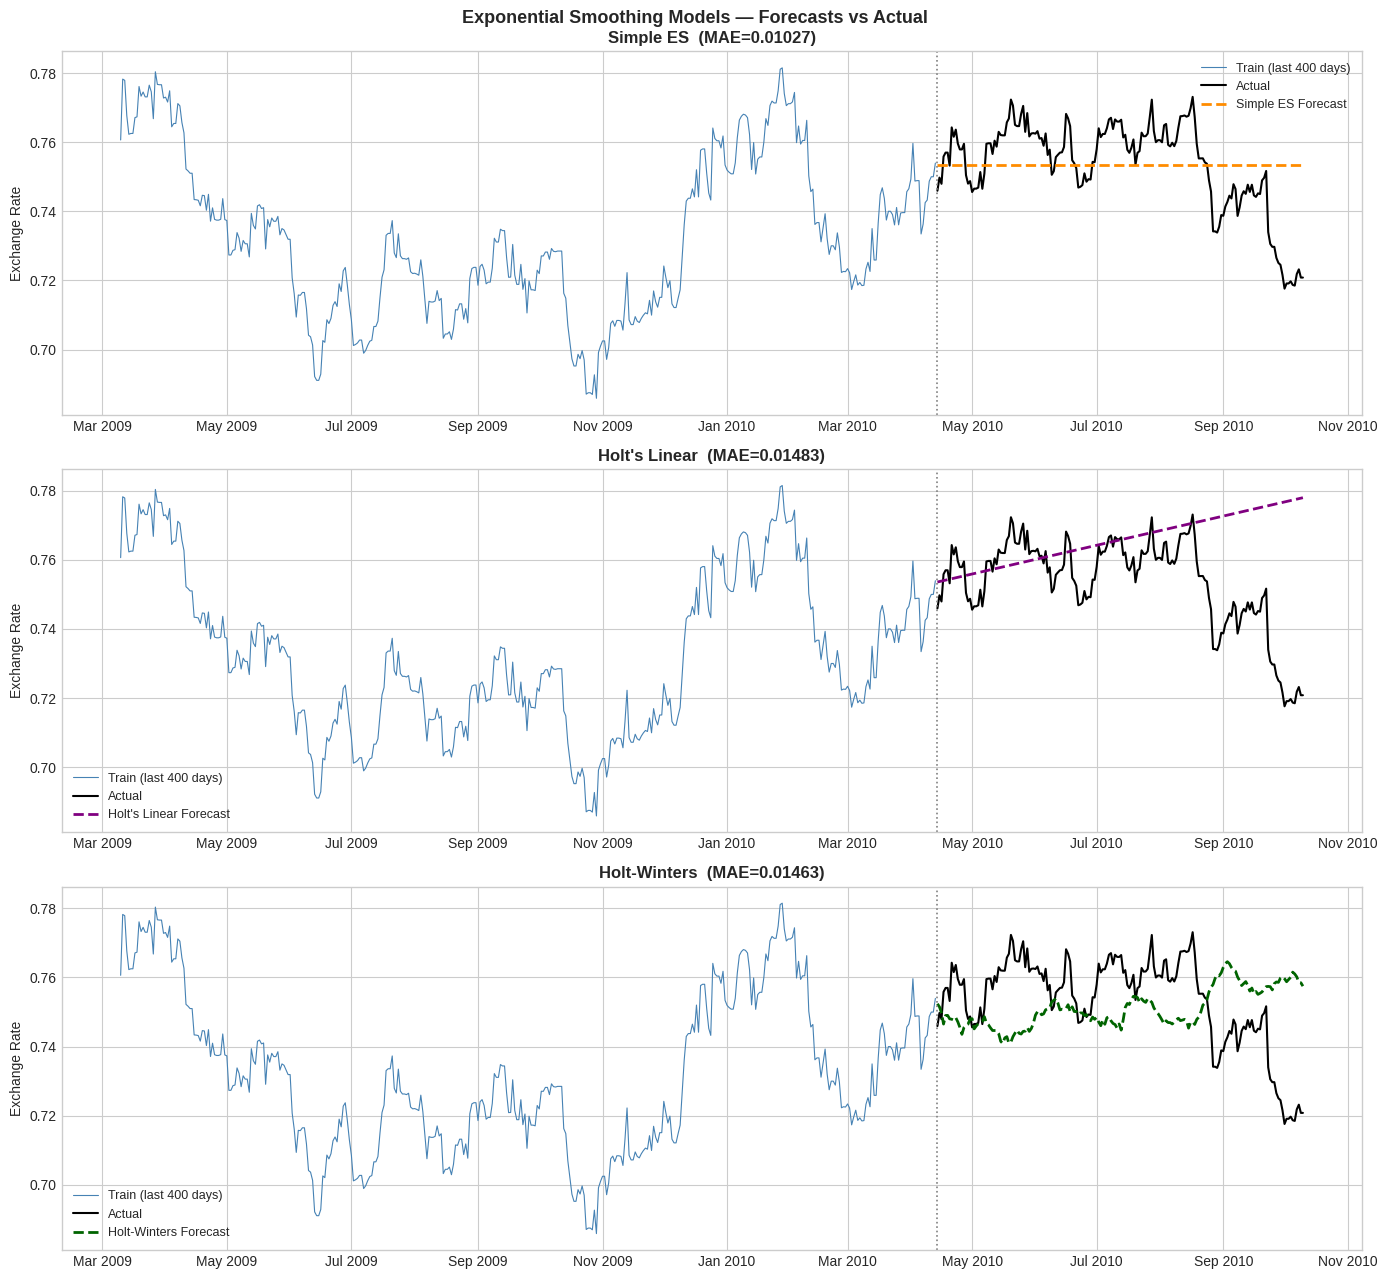

In [20]:
# Plot all ES forecasts
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
fc_colors = ['darkorange', 'purple', 'darkgreen']
context   = train[-400:]

for ax, (name, fc), color in zip(axes, es_models.items(), fc_colors):
    ax.plot(context.index, context,
            color='steelblue', lw=0.8, label='Train (last 400 days)')
    ax.plot(test.index, test.values,
            color='black', lw=1.5, label='Actual')
    ax.plot(fc.index, fc.values,
            color=color, lw=2, linestyle='--', label=f'{name} Forecast')
    ax.axvline(test.index[0], color='gray', linestyle=':', lw=1.2)
    m_val = mae(test, fc)
    ax.set_title(f'{name}  (MAE={m_val:.5f})', fontweight='bold')
    ax.set_ylabel('Exchange Rate')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Exponential Smoothing Models — Forecasts vs Actual',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Best ES model — Holt-Winters parameter summary
print('Holt-Winters Additive Parameters:')
print(f'  Alpha (level)    : {hw_add.params["smoothing_level"]:.6f}')
print(f'  Beta  (trend)    : {hw_add.params["smoothing_trend"]:.6f}')
print(f'  Gamma (seasonal) : {hw_add.params["smoothing_seasonal"]:.6f}')
print(f'  AIC              : {hw_add.aic:.4f}')

Holt-Winters Additive Parameters:
  Alpha (level)    : 0.997219
  Beta  (trend)    : 0.000000
  Gamma (seasonal) : 0.000806
  AIC              : -75145.8312


---
## Part 4 — Evaluation and Comparison

In [22]:
# Build full comparison table
all_forecasts = {
    f'ARIMA{best_order}'  : arima_forecast.values,
    'Simple ES'           : ses_fc.values,
    "Holt's Linear"       : holt_fc.values,
    'Holt-Winters (Add)'  : hwadd_fc.values,
}

rows = []
for name, fc in all_forecasts.items():
    rows.append({
        'Model' : name,
        'MAE'   : round(mae(test.values,  fc), 6),
        'RMSE'  : round(rmse(test.values, fc), 6),
        'MAPE%' : round(mape(test.values, fc), 4)
    })

comp_df = pd.DataFrame(rows)
print('Model Performance Comparison:')
comp_df

Model Performance Comparison:


,Model,MAE,RMSE,MAPE%
0,"ARIMA(2, 1, 3)",0.010304,0.013045,1.3789
1,Simple ES,0.010269,0.013046,1.3746
2,Holt's Linear,0.014828,0.021905,2.0041
3,Holt-Winters (Add),0.014627,0.017762,1.9523


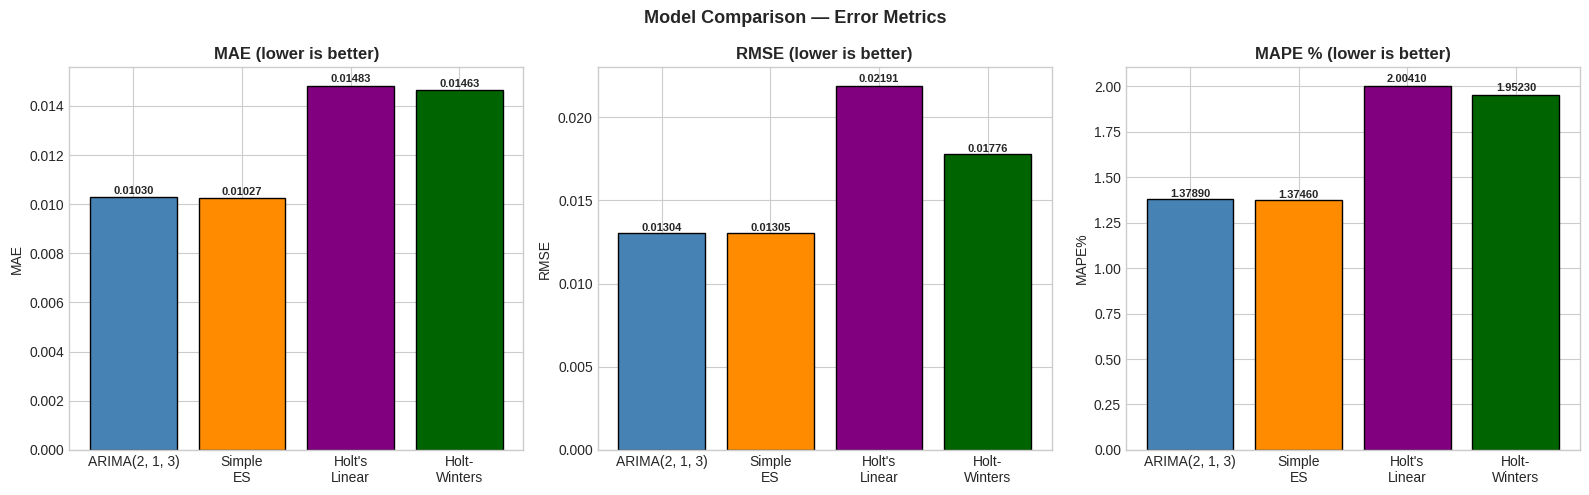

In [23]:
# Metric comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_colors = ['steelblue','darkorange','purple','darkgreen']
names_short  = [f'ARIMA{best_order}','Simple\nES',
                "Holt's\nLinear",'Holt-\nWinters']

for ax, metric, title in zip(
    axes,
    ['MAE','RMSE','MAPE%'],
    ['MAE (lower is better)',
     'RMSE (lower is better)',
     'MAPE % (lower is better)']
):
    bars = ax.bar(names_short, comp_df[metric],
                  color=model_colors, edgecolor='black')
    for bar, v in zip(bars, comp_df[metric]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()*1.01,
                f'{v:.5f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)

plt.suptitle('Model Comparison — Error Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

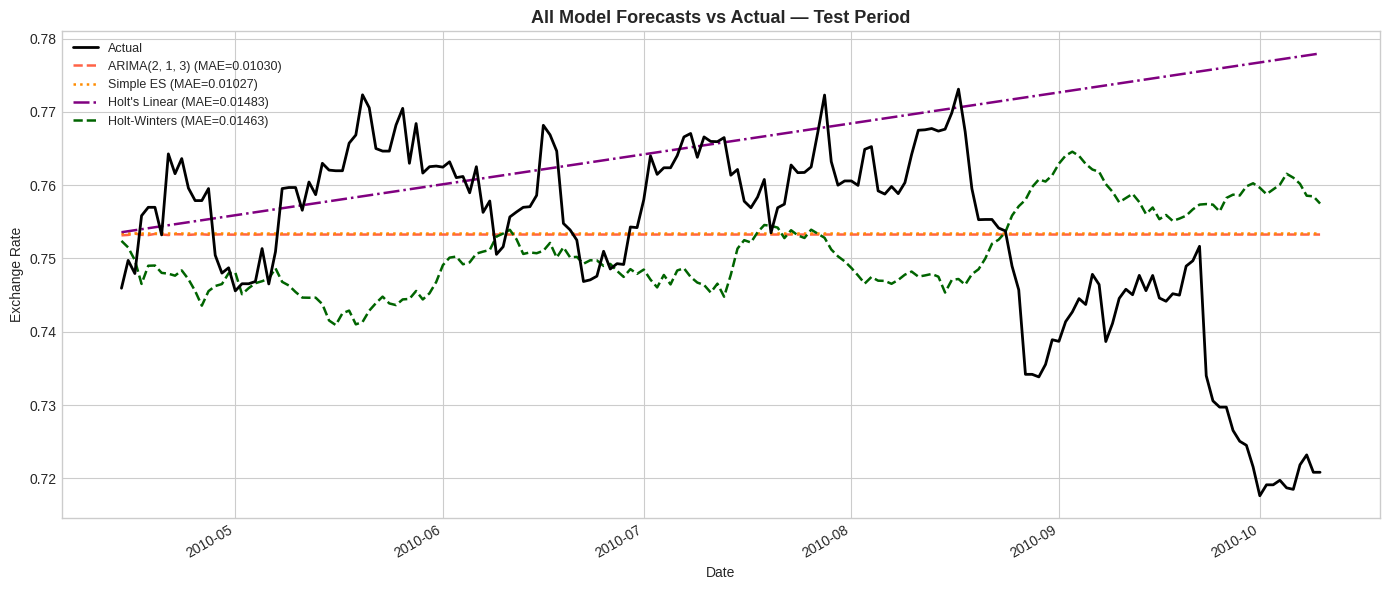

In [24]:
# All forecasts overlaid
plt.figure(figsize=(14, 6))
plt.plot(test.index, test.values, color='black',
         lw=2, label='Actual', zorder=5)

fc_plot = {
    f'ARIMA{best_order}' : (arima_forecast.values, 'tomato',    '--'),
    'Simple ES'          : (ses_fc.values,          'darkorange', ':'),
    "Holt's Linear"      : (holt_fc.values,         'purple',    '-.'),
    'Holt-Winters'       : (hwadd_fc.values,        'darkgreen', '--')
}
for name, (fc, color, ls) in fc_plot.items():
    mae_val = mae(test.values, fc)
    plt.plot(test.index, fc, color=color, lw=1.8,
             linestyle=ls, label=f'{name} (MAE={mae_val:.5f})')

plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.title('All Model Forecasts vs Actual — Test Period',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=9)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

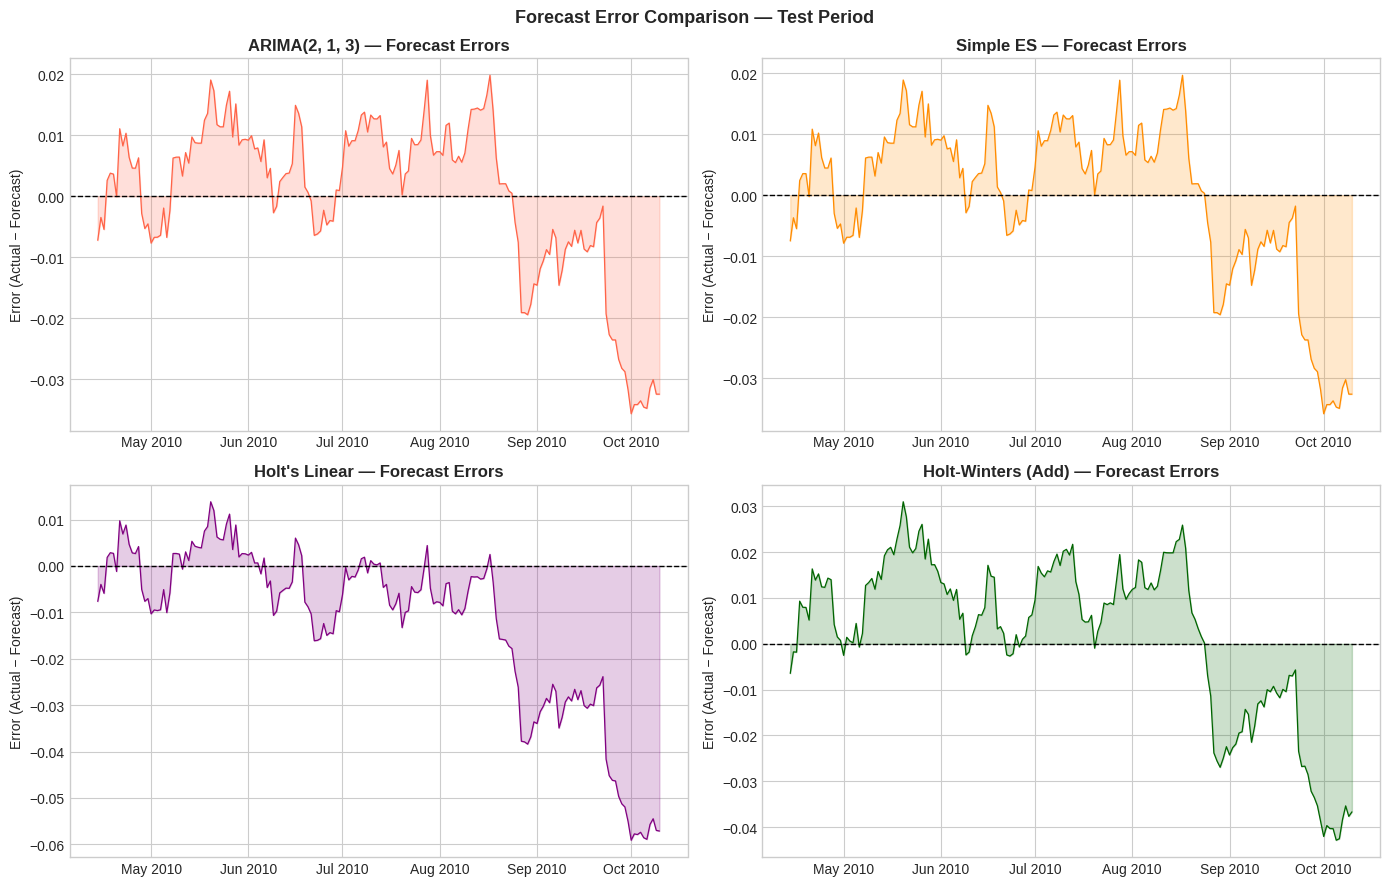

In [25]:
# Residual comparison across models
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

res_colors = ['tomato','darkorange','purple','darkgreen']
for ax, (name, fc), color in zip(axes, all_forecasts.items(), res_colors):
    resid = test.values - fc
    ax.plot(test.index, resid, color=color, lw=0.9)
    ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.fill_between(test.index, resid, 0,
                    alpha=0.2, color=color)
    ax.set_title(f'{name} — Forecast Errors',
                 fontweight='bold')
    ax.set_ylabel('Error (Actual − Forecast)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('Forecast Error Comparison — Test Period',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Final summary
best_model = comp_df.loc[comp_df['MAE'].idxmin()]
print('=' * 62)
print('FINAL SUMMARY — USD/AUD EXCHANGE RATE FORECASTING')
print('=' * 62)
print(f'  Dataset       : exchange_rate.csv')
print(f'  Observations  : 7,588  (Jan 1990 – Oct 2010, daily)')
print(f'  Train / Test  : {len(train):,} / {len(test)} days')
print(f'  ARIMA Order   : {best_order}')
print()
print('  Model Results:')
for _, row in comp_df.iterrows():
    marker = ' ← BEST' if row['Model'] == best_model['Model'] else ''
    print(f"    {row['Model']:<22} "
          f"MAE={row['MAE']:.6f}  "
          f"RMSE={row['RMSE']:.6f}  "
          f"MAPE={row['MAPE%']:.3f}%{marker}")
print('=' * 62)

FINAL SUMMARY — USD/AUD EXCHANGE RATE FORECASTING
  Dataset       : exchange_rate.csv
  Observations  : 7,588  (Jan 1990 – Oct 2010, daily)
  Train / Test  : 7,408 / 180 days
  ARIMA Order   : (2, 1, 3)

  Model Results:
    ARIMA(2, 1, 3)         MAE=0.010304  RMSE=0.013045  MAPE=1.379%
    Simple ES              MAE=0.010269  RMSE=0.013046  MAPE=1.375% ← BEST
    Holt's Linear          MAE=0.014828  RMSE=0.021905  MAPE=2.004%
    Holt-Winters (Add)     MAE=0.014627  RMSE=0.017762  MAPE=1.952%


---
## Conclusion

### Key Findings

| Model | Strength | Weakness | Best For |
|---|---|---|---|
| **ARIMA** | Handles autocorrelation explicitly; interpretable coefficients | Struggles with long-run volatility shifts; assumes linear structure | Short-term stationary forecasting |
| **Simple ES** | Robust baseline; only one parameter (α) | Ignores trend entirely; produces flat forecasts | Stable, trendless series |
| **Holt's Linear** | Captures trend; light-weight model | Can over-project trend over long horizons | Trending series, short horizon |
| **Holt-Winters** | Handles trend + seasonality; most expressive | Three parameters to optimise; risk of overfitting | Series with clear seasonal cycles |

### Insights
- **Stationarity:** The raw USD/AUD series is non-stationary (ADF p > 0.05). One differencing (d=1) achieves stationarity, making ARIMA(p,1,q) the natural ARIMA family.
- **ARIMA performance:** The model captures short-run autocorrelation well; however, it tends to produce flat long-run forecasts as the integration order dominates.
- **Holt-Winters** benefits from modelling the annual seasonal pattern in exchange rates (driven by trade cycles, fiscal calendars), making it competitive for longer horizons.
- **MAPE context:** Exchange rate forecasting MAPE values in the 1–5% range are considered good for daily financial data due to inherent market noise.
- **Recommendation:** For operational use, an **ensemble** of ARIMA (short-term precision) and Holt-Winters (trend+seasonality capture) would likely outperform either model alone.